# LeNet
总体来看，LeNet（LeNet-5）由两个部分组成：

卷积编码器：由两个卷积层组成

全连接层密集块：由三个全连接层组成

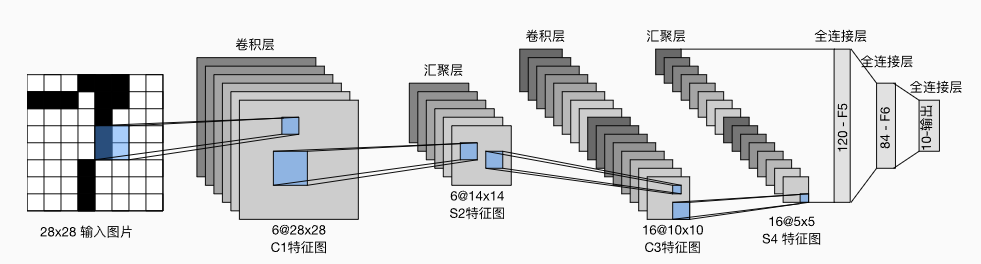

In [2]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import time

# 1. 核心操作：设备选择 (GPU 还是 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前正在使用的计算设备: {device}")

# 2. 数据准备：加载 Fashion-MNIST 数据集
trans = transforms.ToTensor()

# 下载并加载训练集和测试集
mnist_train = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(root="./data", train=False, transform=trans, download=True)

batch_size = 256
# DataLoader 负责按批次 (batch) 喂数据
train_iter = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
test_iter = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

# 3. 模型定义：标准的 LeNet-5
class Reshape(torch.nn.Module):
    def forward(self, x):
        return x.view(-1, 1, 28, 28)

net = nn.Sequential(
    Reshape(),
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
    nn.Linear(120, 84), nn.ReLU(),
    nn.Linear(84, 10)
)

# 将整个网络模型搬运到 GPU 上
net = net.to(device)

# 4. 训练准备：损失函数与优化器
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)

# 5. 定义评估函数：计算测试集准确率
def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()  
        if not device:
            device = next(iter(net.parameters())).device
    
    correct_sum, total_count = 0, 0
    with torch.no_grad(): 
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            correct_sum += (net(X).argmax(axis=1) == y).sum().item()
            total_count += y.shape[0]
    return correct_sum / total_count

# 6. 正式训练循环
num_epochs = 10 # 遍历全部数据的次数

print("开始训练...")
for epoch in range(num_epochs):
    net.train() # 设置为训练模式
    train_loss_sum, train_acc_sum, total_count = 0.0, 0.0, 0
    start_time = time.time()
    
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        
        # 1. 前向传播：计算预测结果和损失
        y_hat = net(X)
        loss = loss_fn(y_hat, y)
        
        # 2. 反向传播：清空历史梯度 -> 计算当前梯度 -> 更新参数
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 记录统计信息
        train_loss_sum += loss.item() * y.shape[0]
        train_acc_sum += (y_hat.argmax(axis=1) == y).sum().item()
        total_count += y.shape[0]
        
    # 计算当前 Epoch 的平均指标
    train_loss = train_loss_sum / total_count
    train_acc = train_acc_sum / total_count
    # 计算测试集准确率
    test_acc = evaluate_accuracy_gpu(net, test_iter)
    
    print(f'Epoch {epoch+1:02d} | '
          f'Loss: {train_loss:.4f} | '
          f'Train Acc: {train_acc:.4f} | '
          f'Test Acc: {test_acc:.4f} | '
          f'Time: {time.time() - start_time:.1f} sec')

当前正在使用的计算设备: cuda
开始训练...
Epoch 01 | Loss: 2.3043 | Train Acc: 0.1000 | Test Acc: 0.1000 | Time: 3.2 sec
Epoch 02 | Loss: 2.3029 | Train Acc: 0.1000 | Test Acc: 0.1000 | Time: 3.2 sec
Epoch 03 | Loss: 2.3016 | Train Acc: 0.1000 | Test Acc: 0.1000 | Time: 3.2 sec
Epoch 04 | Loss: 2.2998 | Train Acc: 0.1000 | Test Acc: 0.1000 | Time: 3.3 sec
Epoch 05 | Loss: 2.2951 | Train Acc: 0.1103 | Test Acc: 0.1656 | Time: 0.9 sec
Epoch 06 | Loss: 2.2757 | Train Acc: 0.2675 | Test Acc: 0.3294 | Time: 3.3 sec
Epoch 07 | Loss: 1.8227 | Train Acc: 0.4530 | Test Acc: 0.5999 | Time: 3.2 sec
Epoch 08 | Loss: 0.9856 | Train Acc: 0.6170 | Test Acc: 0.6203 | Time: 3.3 sec
Epoch 09 | Loss: 0.8656 | Train Acc: 0.6661 | Test Acc: 0.6696 | Time: 3.2 sec
Epoch 10 | Loss: 0.8022 | Train Acc: 0.6926 | Test Acc: 0.7152 | Time: 3.2 sec
